In [64]:
# ============================================================
# Mortgage Rate Optimization (Freddie Mac - Prepared Dataset)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

np.random.seed(42)



In [65]:
# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("Prepared_Dataset.csv")

print("Initial shape:", df.shape)


Initial shape: (148938, 36)


In [66]:
# ------------------------------------------------------------
# 2. BASIC CLEANING
# ------------------------------------------------------------

df = df.dropna()

df = df[
    (df["CreditScore"].between(500, 850)) &
    (df["LTV"].between(10, 100)) &
    (df["DTI"].between(0, 60)) &
    (df["OrigUPB"] > 0) &
    (df["OrigInterestRate"].between(1, 10))
]

print("Clean shape:", df.shape)

Clean shape: (148046, 36)


In [67]:
# ------------------------------------------------------------
# 3. TARGET VARIABLE (SERIOUS DELINQUENCY / DEFAULT)
# ------------------------------------------------------------

df["default_flag"] = (df["MonthsDelinquent"] >= 3).astype(int)


# ------------------------------------------------------------
# 4. FEATURE ENGINEERING
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# ---- Mild Filtering ----

df = df[
    (df["CreditScore"] > 550) &
    (df["LTV"] < 95) &
    (df["DTI"] < 55) &
    (df["OrigUPB"] > 0)
].copy()

print("Default Rate:", round(df["default_flag"].mean(), 4))


# ---- Normalized Continuous Features ----

df["credit_z"] = (df["CreditScore"] - 720) / 50
df["dti_z"] = (df["DTI"] - 30) / 10
df["ltv_z"] = (df["LTV"] - 80) / 10
df["rate_z"] = (df["OrigInterestRate"] - 4) / 1


# ---- Borrower / Loan Features ----

df["first_time_flag"] = (
    df["IsFirstTimeHomebuyer"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
    .fillna(0)
    .astype(int)
)

df["log_upb"] = np.log(df["OrigUPB"])


# ---- Nonlinear Features ----

df["ltv_sq"] = df["ltv_z"] ** 2
df["dti_sq"] = df["dti_z"] ** 2
df["credit_sq"] = df["credit_z"] ** 2


# ---- Interaction Features ----

df["credit_ltv"] = df["credit_z"] * df["ltv_z"]
df["credit_dti"] = df["credit_z"] * df["dti_z"]
df["ltv_dti"] = df["ltv_z"] * df["dti_z"]

# NEW: repayment features (you added these but didn’t use them)
df["log_repay"] = np.log1p(df["MonthsInRepayment"])
df["repay_ltv"] = df["MonthsInRepayment"] * df["ltv_z"]


# ---- One-Hot Encode Range Features ----

df = pd.get_dummies(df, columns=["LTV_range", "Credit_range"], drop_first=True)

range_features = [
    col for col in df.columns
    if col.startswith("LTV_range_") or col.startswith("Credit_range_")
]


# ---- NEW: One-Hot Encode Additional Categorical Features ----

cat_cols = ["ServicerName", "LoanPurpose", "PropertyState", "PropertyType"]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

cat_features = [
    col for col in df.columns
    if any(prefix in col for prefix in [
        "ServicerName_",
        "LoanPurpose_",
        "PropertyState_",
        "PropertyType_"
    ])
]


# ------------------------------------------------------------
# 5. DEFAULT MODEL (XGBOOST + RANDOMIZED SEARCH CV)
# ------------------------------------------------------------

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

features = [
    "credit_z",
    "dti_z",
    "ltv_z",
    "log_upb",
    "rate_z",
    "first_time_flag",
    "ltv_sq",
    "dti_sq",
    "credit_sq",
    "credit_ltv",
    "credit_dti",
    "ltv_dti",
    "log_repay",        # now included
    "repay_ltv"         # now included
] + range_features + cat_features

X = df[features]
y = df["default_flag"]


# ---- Train/Test Split ----

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# ---- Class Imbalance ----

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()


# ---- Base Model ----

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)


# ---- Hyperparameter Space ----

param_dist = {
    "n_estimators": [500, 700, 900],
    "max_depth": [4, 5],
    "learning_rate": [0.005, 0.01, 0.02],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.05, 0.1],
    "reg_lambda": [1, 1.5, 2],
    "reg_alpha": [0, 0.5, 1]
}


# ---- Randomized Search ----

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


# ---- Best Model ----

model_default = random_search.best_estimator_

print("Best Params:", random_search.best_params_)


# ---- Evaluation ----

pd_test = model_default.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pd_test)

print("Tuned Model AUC:", round(auc, 4))

Default Rate: 0.1445
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 900, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.05, 'colsample_bytree': 0.8}
Tuned Model AUC: 0.7867


In [68]:
# ------------------------------------------------------------
# 6. ACCEPTANCE MODEL (SYNTHETIC)
# ------------------------------------------------------------

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def acceptance_prob(row, r):
    credit_z = (row["CreditScore"] - 720) / 50
    dti_z = (row["DTI"] - 30) / 10
    ltv_z = (row["LTV"] - 80) / 10

    rate_z = (r - 0.04) / 0.005  # VERY IMPORTANT

    logit = (
        1.2
        + 0.8 * credit_z
        - 0.7 * dti_z
        - 0.6 * ltv_z
        - 1.5 * rate_z
    )

    return sigmoid(logit)

In [69]:
# ------------------------------------------------------------
# 7. EXPECTED PROFIT FUNCTION
# ------------------------------------------------------------

def expected_profit(row, r):
    # default probability (real model)
    temp = row.copy()
    temp["rate_z"] = (r - 0.04) / 1

    X_one = pd.DataFrame([temp[features]])
    pd_default = model_default.predict_proba(X_one)[0, 1]

    # acceptance probability (synthetic)
    pa = acceptance_prob(row, r)

    L = row["OrigUPB"]
    T = 5
    cost_of_funds = 0.025

    # simple LGD approximation
    lgd = 0.2 + 0.4 * ((row["LTV"] / 100) - 0.8)
    lgd = np.clip(lgd, 0.1, 0.6)

    acquisition_cost = 1000

    profit = (
        L * (r - cost_of_funds) * T
        - pd_default * lgd * L
        - acquisition_cost
    )

    return pa * profit

In [70]:
# ------------------------------------------------------------
# 8. OPTIMIZATION FUNCTION
# ------------------------------------------------------------

def optimize_rate(row, epsilon=0.05):
    rates = np.linspace(0.03, 0.065, 141)

    profits = np.array([expected_profit(row, r) for r in rates])

    max_profit = np.max(profits)
    opt_rate = rates[np.argmax(profits)]

    # handle negative profit case safely
    if max_profit > 0:
        threshold = (1 - epsilon) * max_profit
    else:
        threshold = max_profit

    valid = rates[profits >= threshold]

    if len(valid) == 0:
        constrained_rate = opt_rate
    else:
        constrained_rate = np.min(valid)

    return opt_rate, constrained_rate, max_profit, rates, profits

In [73]:
# ------------------------------------------------------------
# 9. RUN EXPERIMENT
# ------------------------------------------------------------

sample_df = df.sample(min(1000, len(df)), random_state=42)

rates = np.linspace(0.03, 0.065, 60)

from tqdm import tqdm
import numpy as np

opt_rates = []
cons_rates = []

opt_profits = []
cons_profits = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    opt_r, cons_r, max_profit, _, _ = optimize_rate(row)

    # Profit at constrained rate
    cons_profit = expected_profit(row, cons_r)

    opt_rates.append(opt_r)
    cons_rates.append(cons_r)

    opt_profits.append(max_profit)
    cons_profits.append(cons_profit)

# Convert to arrays for safe math
opt_profits = np.array(opt_profits)
cons_profits = np.array(cons_profits)

# Compute profit gap (safe division)
profit_gap = np.mean(
    (opt_profits - cons_profits) / np.maximum(opt_profits, 1e-6)
)

# Store results
sample_df["opt_rate"] = opt_rates
sample_df["cons_rate"] = cons_rates
sample_df["opt_profit"] = opt_profits
sample_df["cons_profit"] = cons_profits

# Print summary
print("Avg Optimal Rate:", np.mean(opt_rates))
print("Avg Constrained Rate:", np.mean(cons_rates))
print("Avg Reduction (bps):", 10000 * (np.mean(opt_rates) - np.mean(cons_rates)))
print("Average Profit Gap (%):", round(100 * profit_gap, 2))

100%|██████████| 1000/1000 [20:47<00:00,  1.25s/it]

Avg Optimal Rate: 0.04706675
Avg Constrained Rate: 0.04581874999999999
Avg Reduction (bps): 12.48000000000006
Average Profit Gap (%): 3.97


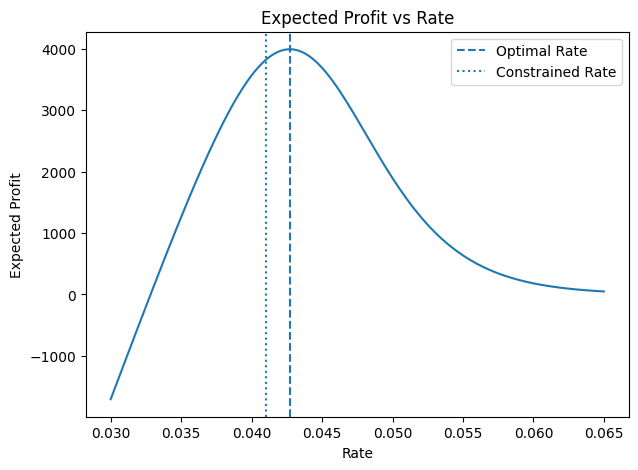

In [76]:
# ------------------------------------------------------------
# 10. PLOT 1: PROFIT VS RATE (CRITICAL)
# ------------------------------------------------------------

row = sample_df.iloc[0]
opt_r, cons_r, _, rates, profits = optimize_rate(row)

plt.figure(figsize=(7,5))
plt.plot(rates, profits)
plt.axvline(opt_r, linestyle="--", label="Optimal Rate")
plt.axvline(cons_r, linestyle=":", label="Constrained Rate")
plt.xlabel("Rate")
plt.ylabel("Expected Profit")
plt.title("Expected Profit vs Rate")
plt.legend()
plt.savefig("profit_vs_rate.png")
plt.show()

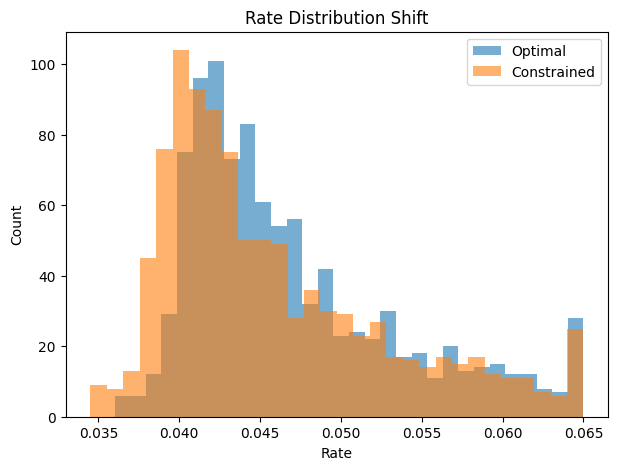

In [77]:
# ------------------------------------------------------------
# 11. PLOT 2: DISTRIBUTION SHIFT (VERY IMPORTANT)
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
plt.hist(opt_rates, bins=30, alpha=0.6, label="Optimal")
plt.hist(cons_rates, bins=30, alpha=0.6, label="Constrained")
plt.xlabel("Rate")
plt.ylabel("Count")
plt.title("Rate Distribution Shift")
plt.legend()
plt.savefig("rate_distribution.png")
plt.show()

100%|██████████| 1000/1000 [20:23<00:00,  1.22s/it]


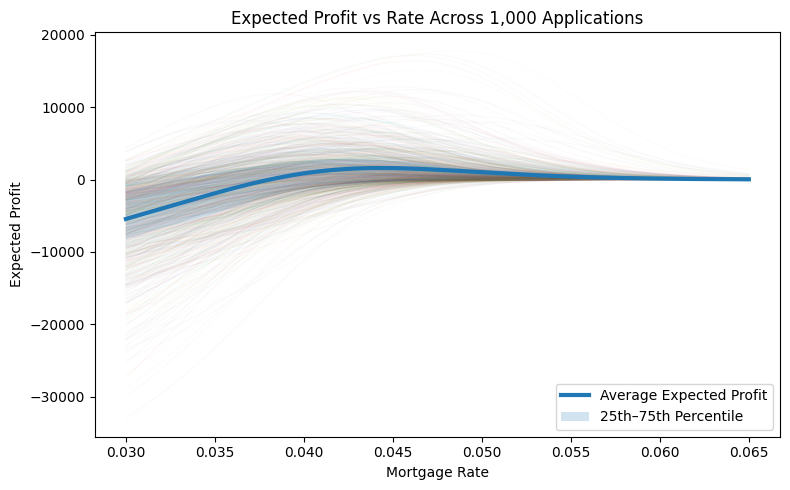

In [78]:
# ------------------------------------------------------------
# PLOT: PROFIT VS RATE FOR ALL SAMPLE APPLICATIONS
# ------------------------------------------------------------

all_profit_curves = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    _, _, _, rates, profits = optimize_rate(row)
    all_profit_curves.append(profits)

all_profit_curves = np.array(all_profit_curves)

mean_profit = all_profit_curves.mean(axis=0)
p25_profit = np.percentile(all_profit_curves, 25, axis=0)
p75_profit = np.percentile(all_profit_curves, 75, axis=0)

plt.figure(figsize=(8, 5))

# faint individual curves
for profits in all_profit_curves[:1000]:
    plt.plot(rates, profits, alpha=0.03, linewidth=0.7)

# average curve
plt.plot(rates, mean_profit, linewidth=3, label="Average Expected Profit")

# interquartile band
plt.fill_between(rates, p25_profit, p75_profit, alpha=0.2, label="25th–75th Percentile")

plt.xlabel("Mortgage Rate")
plt.ylabel("Expected Profit")
plt.title("Expected Profit vs Rate Across 1,000 Applications")
plt.legend()
plt.tight_layout()
plt.savefig("profit_vs_rate_all_samples.png", dpi=300)
plt.show()

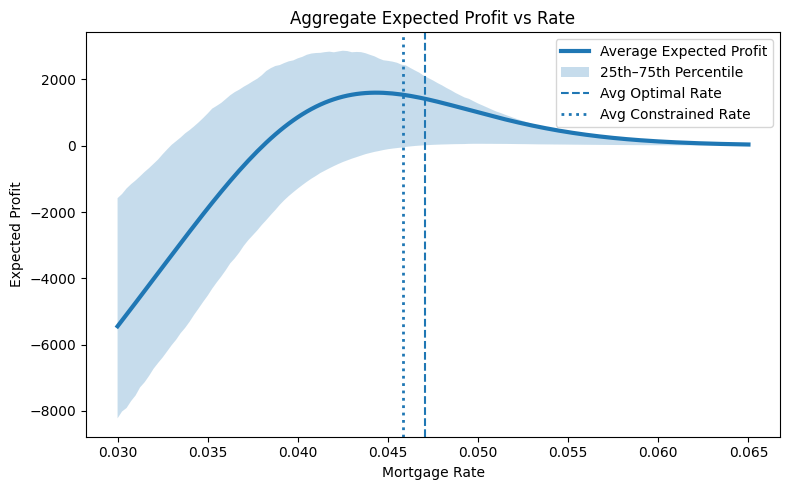

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(rates, mean_profit, linewidth=3, label="Average Expected Profit")
plt.fill_between(rates, p25_profit, p75_profit, alpha=0.25, label="25th–75th Percentile")

# vertical lines
opt_rate_mean = np.mean(opt_rates)
cons_rate_mean = np.mean(cons_rates)

plt.axvline(opt_rate_mean, linestyle="--", linewidth=1.5, label="Avg Optimal Rate")
plt.axvline(cons_rate_mean, linestyle=":", linewidth=2, label="Avg Constrained Rate")

plt.xlabel("Mortgage Rate")
plt.ylabel("Expected Profit")
plt.title("Aggregate Expected Profit vs Rate")

plt.legend()
plt.tight_layout()
plt.show()